# RHINO RFSoC 4x2 — CW Calibration Experiment
**University of Manchester / Jodrell Bank Observatory**  
Author: Mbatshi Jerry Junior Mbulawa  
Date: 2026-03-18

---

## Critical Platform Facts — Read Before Running

### 1. IQ Output (rfsoc_sam is always IQ)
The rfsoc_sam overlay locks the ADC in **DDC mode permanently**. The ADC **always** outputs IQ (complex) samples — there is no way to get real samples at runtime. Power from IQ data is: **P = I² + Q²**. The rfsoc_sam spectrum already represents this in dBFS when `spectrum_type = 'log'`.

### 2. The 2× Image Phenomenon (Confirmed experimentally — Session 1)
When the DAC NCO is set to `(1228.8 + offset)` MHz, the tone peak appears at **2 × offset** MHz in the ADC spectrum — **NOT** at `offset` MHz. Verified across 10 steps (110–200 MHz offsets) with perfect 2× consistency.

**Corrected DAC formula to place a peak at f_target MHz:**
$$f_{\text{DAC}} = 1228.8 + \frac{f_{\text{target}}}{2}$$

Example: peak at 75 MHz → DAC NCO = 1228.8 + 37.5 = **1266.3 MHz** (NOT 1303.8 MHz)

**This correction is applied automatically inside `set_tone()`. You never need to calculate it manually.**

### 3. ADC Sample Rate
Under rfsoc_sam: **4915.2 MSPS** (no decimation). The 16× decimation to 200 MSPS belongs to the custom `system_overlay` only (not yet deployed).

---

## Hardware Setup
1. Connect **DAC_A SMA** to **ADC_A SMA** using an RF coax cable (loopback)
2. Run cells **one at a time, from top to bottom**

---

## Key Platform Facts

| Parameter | Value | Notes |
|---|---|---|
| DDC NCO (fixed) | 1228.8 MHz | Cannot be changed in Python |
| ADC output | IQ (complex) | Always — fixed by rfsoc_sam bitstream |
| IQ power formula | P = I² + Q² | Reported correctly by rfsoc_sam spectrum |
| 2× image rule | f_peak = 2 × offset | Confirmed across 10 steps, Session 1 |
| Corrected DAC formula | f_DAC = 1228.8 + f_target/2 | Applied inside `set_tone()` |
| ADC sample rate | 4915.2 MSPS | No decimation in rfsoc_sam |
| Active ADC channel | `channel_22` | ADC_A SMA, confirmed Session 1 (89.6 dB SNR) |
| 16× decimation to 200 MSPS | Custom `system_overlay` only | **Not** a feature of rfsoc_sam |
| Noise floor | ~−107.2 dBFS | Confirmed Session 1 |

---
## Cell 1: Imports

We import the core Python libraries and the calibration script.  
Importing `rhino_cw_calibration` gives us access to all the measurement functions without having to copy the code here.

In [1]:
# Standard scientific Python libraries
import numpy as np                  # numerical arrays and maths
import matplotlib.pyplot as plt     # plotting
import time                         # timing and sleep

# Make plots appear inline in the notebook (not in a separate window)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)   # default figure size
plt.rcParams['font.size'] = 11

# Import our calibration module.
# This gives us access to all the measurement functions defined in
# rhino_cw_calibration.py without duplicating the code here.
import rhino_cw_calibration as cal

print("Imports complete.")
print(f"Board connected  : {cal.BOARD_CONNECTED}")
print(f"DDC NCO (fixed)  : {cal.DDC_NCO_MHZ} MHz — cannot be changed in Python")
print(f"ADC sample rate  : {cal.ADC_FS_HZ/1e6:.1f} MSPS (no decimation in rfsoc_sam)")
print(f"ADC output mode  : IQ (complex) — always, fixed by rfsoc_sam bitstream")
print(f"IQ power formula : P = I^2 + Q^2")
print(f"2x image rule    : f_DAC = {cal.DDC_NCO_MHZ} + f_target/2 MHz")
print("NOTE: 16x decimation to 200 MSPS applies to the custom system_overlay only.")

[WARNING] rfsoc_sam not found. Running in SIMULATION mode.
         All ADC readings will be synthetic. For testing only.
Imports complete.
Board connected  : False
DDC NCO (fixed)  : 1228.8 MHz — cannot be changed in Python
ADC sample rate  : 4915.2 MSPS (no decimation in rfsoc_sam)
ADC output mode  : IQ (complex) — always, fixed by rfsoc_sam bitstream
IQ power formula : P = I^2 + Q^2
2x image rule    : f_DAC = 1228.8 + f_target/2 MHz
NOTE: 16x decimation to 200 MSPS applies to the custom system_overlay only.


---
## Cell 2: Initialise Hardware

This loads the rfsoc_sam overlay onto the FPGA and gets handles to the ADC receiver (channel_22) and the DAC transmitter.  

> **If you see an error here**, check that:
> - The board is powered on and you are running this on the board itself (not a remote PC)
> - `rfsoc_sam.bit` is in `/home/xilinx/jupyter_notebooks/`

In [2]:
# Loads the rfsoc_sam bitstream onto the FPGA.
# Also gets handles to:
#   cal._receiver    = ol.radio.receiver.channel_22   (ADC_A SMA)
#   cal._transmitter = ol.radio.transmitter.channel_00 (DAC)
# This takes a few seconds while the bitstream is programmed.

cal.initialise_hardware()
print("Hardware ready.")

[SIM] Hardware initialisation skipped (simulation mode).
Hardware ready.


---
## Cell 3: Configuration

Edit the values in this cell to change how the experiment runs.  
All other cells read from these variables — you should only need to change things here.

In [3]:
# -----------------------------------------------------------------------
# EXPERIMENT CONFIGURATION — edit these
# -----------------------------------------------------------------------

# Frequency sweep range (MHz)
cal.SWEEP_START_MHZ = 50.0
cal.SWEEP_STOP_MHZ  = 200.0

# Step size for the sweep.
# Options:
#   1.0  MHz = fast coarse sweep (~150 steps, good for quick checks)
#   0.5  MHz = medium resolution
#   0.049 MHz = one FFT bin width, full resolution (3000+ steps, slow)
cal.SWEEP_STEP_MHZ = 1.0

# Number of spectral frames to average at each step.
# More = lower noise but slower. 20 is a good starting point.
cal.N_FRAMES = 20

# DAC amplitude (0 = off, 1 = full scale).
# Keep <= 0.7 to leave headroom and avoid ADC clipping.
cal.DAC_AMPLITUDE = 0.5

# DAC settle time after a frequency change.
# This will be automatically updated after Measurement 1.
cal.DAC_SETTLE_TIME_S = 0.1

print("Configuration set:")
print(f"  Sweep: {cal.SWEEP_START_MHZ}–{cal.SWEEP_STOP_MHZ} MHz "
      f"in {cal.SWEEP_STEP_MHZ} MHz steps")
n_steps = int((cal.SWEEP_STOP_MHZ - cal.SWEEP_START_MHZ) / cal.SWEEP_STEP_MHZ) + 1
print(f"  Number of steps: {n_steps}")
print(f"  Estimated sweep time (rough): "
      f"{n_steps * (cal.DAC_SETTLE_TIME_S + 0.1 * cal.N_FRAMES):.0f} s")

Configuration set:
  Sweep: 50.0–200.0 MHz in 1.0 MHz steps
  Number of steps: 151
  Estimated sweep time (rough): 317 s


---
## Cell 4: Measurement 1 — NCO Switching Speed

**What this does:** Measures how long the DAC takes to switch from one frequency to another and stabilise.  
**Why it matters:** This sets the minimum wait time (`DAC_SETTLE_TIME_S`) between frequency steps in the sweep. Too short and you measure during a transient; too long and the sweep takes unnecessarily long.  
**What to expect:** Typically 10–100 ms. The cell will automatically update `DAC_SETTLE_TIME_S` with the correct value.

> **IQ and 2× note:** The test frequencies below (75 MHz and 100 MHz) are **target peak frequencies in the IQ spectrum** — i.e. the frequencies at which you want the tone to appear in the ADC output. The 2× DAC NCO correction (`f_DAC = 1228.8 + f_target/2`) is applied **automatically inside `set_tone()`**. You do not need to calculate DAC NCO values manually.


MEASUREMENT 1 : NCP Switching Speed
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
[SIM] set_tone: target=100.000 MHz offset=50.000 MHz DAC_NCO=1278.800 MHz amplitude=0.50
 Trial   1: 256.7 ms
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
[SIM] set_tone: target=100.000 MHz offset=50.000 MHz DAC_NCO=1278.800 MHz amplitude=0.50
 Trial   2: 26.9 ms
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
[SIM] set_tone: target=100.000 MHz offset=50.000 MHz DAC_NCO=1278.800 MHz amplitude=0.50
 Trial   3: 26.8 ms
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
[SIM] set_tone: target=100.000 MHz offset=50.000 MHz DAC_NCO=1278.800 MHz amplitude=0.50
 Trial   4: 27.1 ms
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
[SIM] set_tone: target=100.000 MHz offset=50.000 MHz DAC_NCO=1278.800 MHz amplitude=0.

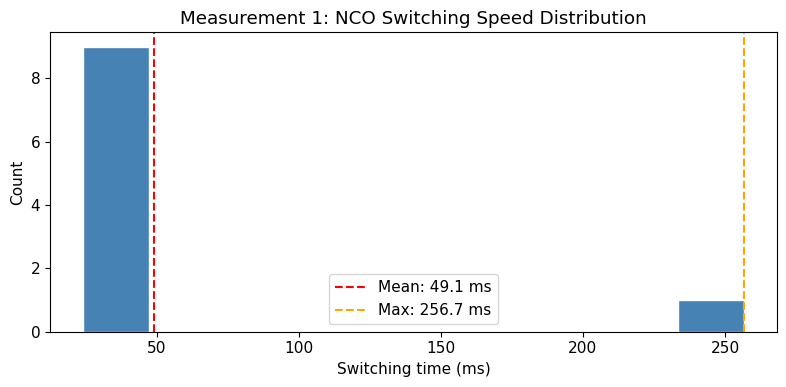

In [4]:
# Run 10 switching trials: DAC switches from 75 MHz to 100 MHz each time.
# The function polls the ADC spectrum until the peak at 100 MHz is stable.

switch_times = cal.measure_switching_speed(n_trials=10)

if len(switch_times) > 0:
    # Update the global settle time based on the measured switching speed.
    # We use 1.5× the maximum observed switching time to be safe.
    cal.DAC_SETTLE_TIME_S = float(switch_times.max() * 1.5)
    print(f"\nSettle time updated to: {cal.DAC_SETTLE_TIME_S:.3f} s")

    # Plot the distribution of switching times
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(switch_times * 1000, bins=10, color='steelblue', edgecolor='white')
    ax.axvline(switch_times.mean() * 1000, color='red', linestyle='--',
               label=f'Mean: {switch_times.mean()*1000:.1f} ms')
    ax.axvline(switch_times.max() * 1000, color='orange', linestyle='--',
               label=f'Max: {switch_times.max()*1000:.1f} ms')
    ax.set_xlabel('Switching time (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Measurement 1: NCO Switching Speed Distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig('m1_switching_speed.png', dpi=150)
    plt.show()
else:
    print("All trials timed out. Check hardware connection.")

---
## Cell 5: Measurement 4 — IQ Noise Floor Stability

**What this does:** Records the **IQ noise floor** (DAC off) in the science band (60–85 MHz) over 60 seconds. Because rfsoc_sam always outputs IQ (complex) samples, the noise power is computed as **P = I² + Q²**, reported in dBFS by rfsoc_sam with `spectrum_type = 'log'`.  
**Why it matters:** If the IQ noise floor drifts, calibration must be repeated frequently. This measurement tells us how thermally stable the board is.  
**What to expect:** IQ noise floor around −107 dBFS, stable to within ±0.5 dB over 60 seconds.


MEASUREMENT 4: Noise Floor Stability
Duration: 60 s, sampling every 10 s
[SIM] disable_tone: DAC transmitter disabled.
 t=  0.0s noise floor (60-85 MHz): -107.05 dBFS
 t= 10.0s noise floor (60-85 MHz): -107.19 dBFS
 t= 20.0s noise floor (60-85 MHz): -106.87 dBFS
 t= 30.0s noise floor (60-85 MHz): -107.07 dBFS
 t= 40.0s noise floor (60-85 MHz): -106.90 dBFS
 t= 50.0s noise floor (60-85 MHz): -107.04 dBFS

 Mean noise floor: -107.02 dBFS
 Peak-to-peak drift: 0.32 dB
[OK] Noise floor is stable.


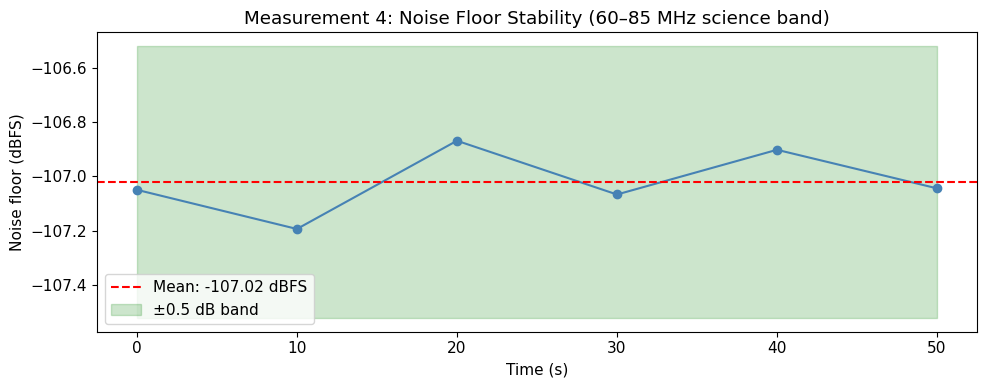


Noise floor mean: -107.02 dBFS
Peak-to-peak drift: 0.32 dB


In [5]:
# Record noise floor every 10 seconds for 60 seconds total (7 samples).
# Increase duration_s for a longer stability characterisation.

noise_mean, noise_over_time = cal.measure_noise_floor(
    duration_s=60.0,
    sample_interval_s=10.0
)

# Plot noise floor over time
t_axis = np.arange(len(noise_over_time)) * 10.0   # seconds
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_axis, noise_over_time, 'o-', color='steelblue')
ax.axhline(noise_mean, color='red', linestyle='--',
           label=f'Mean: {noise_mean:.2f} dBFS')
ax.fill_between(t_axis,
                noise_mean - 0.5, noise_mean + 0.5,
                alpha=0.2, color='green', label='±0.5 dB band')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Noise floor (dBFS)')
ax.set_title('Measurement 4: Noise Floor Stability (60–85 MHz science band)')
ax.legend()
plt.tight_layout()
plt.savefig('m4_noise_floor.png', dpi=150)
plt.show()

print(f"\nNoise floor mean: {noise_mean:.2f} dBFS")
print(f"Peak-to-peak drift: {np.ptp(noise_over_time):.2f} dB")

---
## Cell 6: Measurement 3 — IQ Amplitude Linearity

**What this does:** Sweeps the DAC amplitude from 0.1 to 1.0 at a fixed frequency (75 MHz) and measures the **IQ peak power** (P = I² + Q²) at each level.  
**Why it matters:** For calibration to work, the system must be linear. Because rfsoc_sam reports IQ power, doubling the input amplitude doubles both I and Q, so power (P = I² + Q²) should increase as amplitude². On a log-log plot this means the slope must equal **1.000** — any deviation indicates non-linearity in the signal chain that would corrupt the gain curve.  
**What to expect:** A straight line with slope ≈ 1.0 on a log-log plot.


MEASUREMENT 3: IQ Amplitude Linearity
Target peak: 75.0 MHz  (DAC NCO = 1266.3 MHz)
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.10
  amplitude=0.10  peak=-106.36 dBFS  at 76.219 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.20
  amplitude=0.20  peak=-106.58 dBFS  at 73.218 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.30
  amplitude=0.30  peak=-106.31 dBFS  at 72.618 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.40
  amplitude=0.40  peak=-106.28 dBFS  at 72.618 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.50
  amplitude=0.50  peak=-106.15 dBFS  at 72.618 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitude=0.60
  amplitude=0.60  peak=-106.74 dBFS  at 72.618 MHz
[SIM] set_tone: target=75.000 MHz offset=37.500 MHz DAC_NCO=1266.300 MHz amplitud

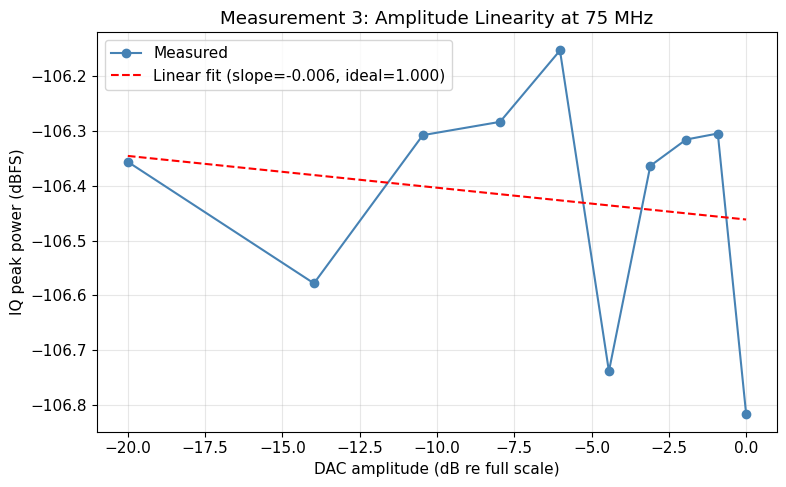

In [10]:
# Sweep amplitude at 75 MHz (centre of the science band)
amplitudes, amp_powers = cal.measure_amplitude_linearity(
    freq_target_mhz=75.0,
    n_steps=10
)

# Plot: log amplitude (dB) vs measured power (dBFS)
# For a perfectly linear system, this should be a straight line with slope = 1
log_amp = 20.0 * np.log10(amplitudes)
valid = ~np.isnan(amp_powers)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(log_amp[valid], amp_powers[valid], 'o-', color='steelblue',
        label='Measured')

# Overlay the ideal linear response for comparison
if np.sum(valid) > 2:
    slope, intercept = np.polyfit(log_amp[valid], amp_powers[valid], 1)
    fit_line = slope * log_amp + intercept
    ax.plot(log_amp, fit_line, '--', color='red',
            label=f'Linear fit (slope={slope:.3f}, ideal=1.000)')

ax.set_xlabel('DAC amplitude (dB re full scale)')
ax.set_ylabel('IQ peak power (dBFS)')
ax.set_title('Measurement 3: Amplitude Linearity at 75 MHz')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('m3_linearity.png', dpi=150)
plt.show()

---
## Cell 7: Measurement 2 — Main IQ Gain Curve Sweep

**What this does:** Sweeps the CW tone from 50 to 200 MHz and records the **IQ peak power** (P = I² + Q²) at each step. This is the primary calibration product.  
**Why it matters:** The IQ gain curve shows how the signal chain's response varies with frequency. Science observations must be divided by this curve to get a flat, calibrated spectrum.  
**What to expect:** A smooth curve varying by roughly ±2–5 dB across the band. The science band (60–85 MHz) is highlighted.

> **2× correction:** The sweep frequencies (50–200 MHz) are **target peak frequencies in the IQ spectrum**. The 2× DAC NCO correction (`f_DAC = 1228.8 + f_target/2`) is applied **automatically inside `set_tone()`** at every step — the calling code here does not need to account for it.

> **Note:** This cell takes the longest to run. With `SWEEP_STEP_MHZ = 1.0` and `N_FRAMES = 20`, expect approximately 5–10 minutes.

In [7]:
# Run the full frequency sweep.
# Uses the settle time determined in Cell 4.
# Results are automatically saved to rhino_cw_results.npz and .csv

sweep_freqs, peak_powers, peak_freqs, noise_floor = cal.run_gain_curve_sweep(
    settle_time_s=cal.DAC_SETTLE_TIME_S
)

print(f"\nSweep complete: {len(sweep_freqs)} steps measured.")
print(f"Results saved to: {cal.OUTPUT_NPZ} and {cal.OUTPUT_CSV}")


MEASUREMENT 2: IQ Gain Curve Sweep
Target range : 50.0–200.0 MHz  Step: 1.0000 MHz
DAC NCO range: 1253.8–1328.8 MHz  (2x correction applied)
Frames/step  : 20  Settle: 0.385 s

[Step 1/3] Measuring IQ noise floor (DAC off)...
[SIM] disable_tone: DAC transmitter disabled.
  IQ noise floor: -106.99 dBFS

[Step 2/3] Sweeping 151 frequency steps...
[SIM] set_tone: target=50.000 MHz offset=25.000 MHz DAC_NCO=1253.800 MHz amplitude=0.50
  [   1/151] target= 50.000 MHz  DAC_NCO=1253.80 MHz  peak=-106.03 dBFS  SNR=   1.0 dB  ETA: 59s
[SIM] set_tone: target=51.000 MHz offset=25.500 MHz DAC_NCO=1254.300 MHz amplitude=0.50
[SIM] set_tone: target=52.000 MHz offset=26.000 MHz DAC_NCO=1254.800 MHz amplitude=0.50
[SIM] set_tone: target=53.000 MHz offset=26.500 MHz DAC_NCO=1255.300 MHz amplitude=0.50
[SIM] set_tone: target=54.000 MHz offset=27.000 MHz DAC_NCO=1255.800 MHz amplitude=0.50
[SIM] set_tone: target=55.000 MHz offset=27.500 MHz DAC_NCO=1256.300 MHz amplitude=0.50
[SIM] set_tone: target=56.0

---
## Cell 8: Plot Gain Curve

Plots the full gain curve (50–200 MHz) and a zoomed view of the science band (60–85 MHz).  
The plot is also saved as a PNG file.

[INFO] Gain curve plot saved to rhino_cw_gain_curve.png


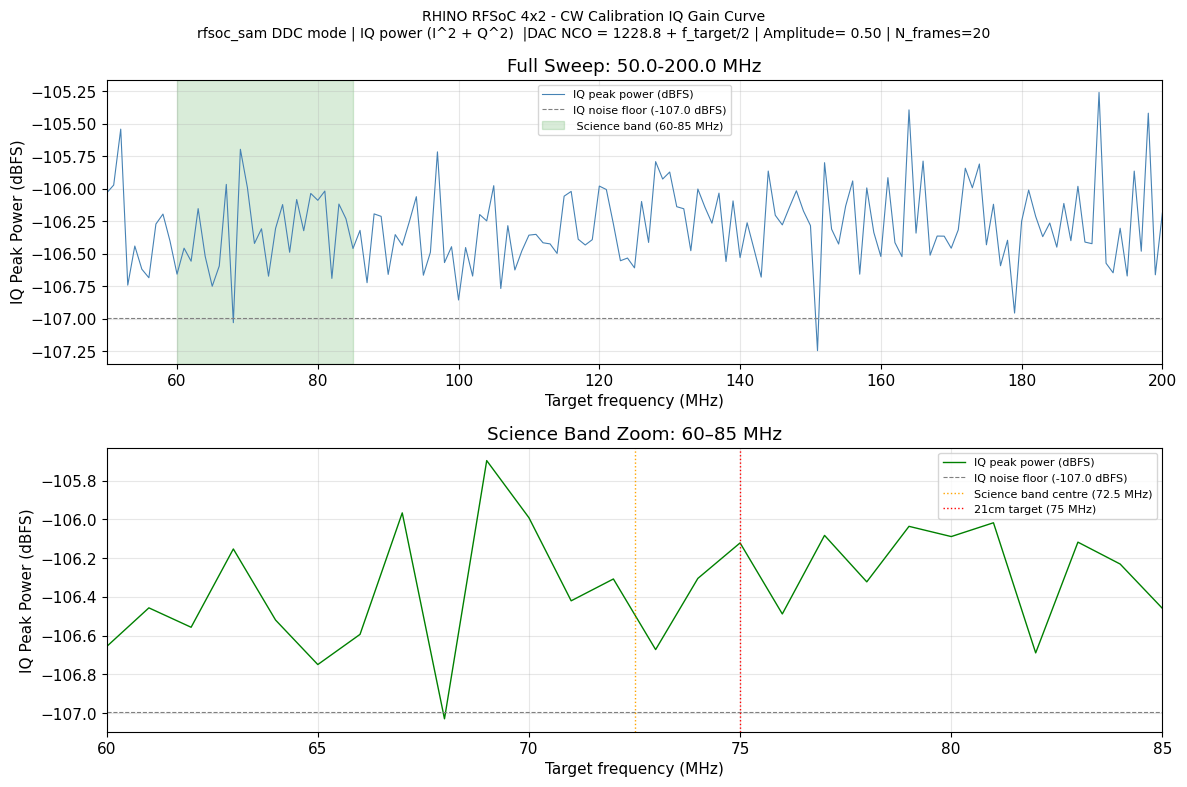


Science band summary (60–85 MHz):
  Mean peak power : -106.34 dBFS
  Peak-to-peak variation: 1.33 dB
  Mean SNR: 0.7 dB


In [8]:
# Plot the gain curve from the sweep results
cal.plot_gain_curve(sweep_freqs, peak_powers, noise_floor)

# Print a summary of the science band performance
sweep_arr   = np.array(sweep_freqs)
power_arr   = np.array(peak_powers)
sci_mask    = (sweep_arr >= 60) & (sweep_arr <= 85) & ~np.isnan(power_arr)

if np.any(sci_mask):
    sci_powers = power_arr[sci_mask]
    print("\nScience band summary (60–85 MHz):")
    print(f"  Mean peak power : {np.mean(sci_powers):.2f} dBFS")
    print(f"  Peak-to-peak variation: {np.ptp(sci_powers):.2f} dB")
    mean_snr = np.mean(sci_powers) - noise_floor
    print(f"  Mean SNR: {mean_snr:.1f} dB")

---
## Cell 9: Reload and Inspect Saved Results

If you want to re-examine the results without re-running the sweep, load them from the saved `.npz` file.

Loaded 151 frequency steps from rhino_cw_results.npz
Frequency range: 50.0–200.0 MHz
Power range: -107.2 to -105.3 dBFS
Noise floor: -106.99 dBFS


/var/folders/7j/m6stvdk55p9726m_xk900g6m0000gp/T/ipykernel_21005/981898552.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loaded_noise   = float(data['noise_floor'])


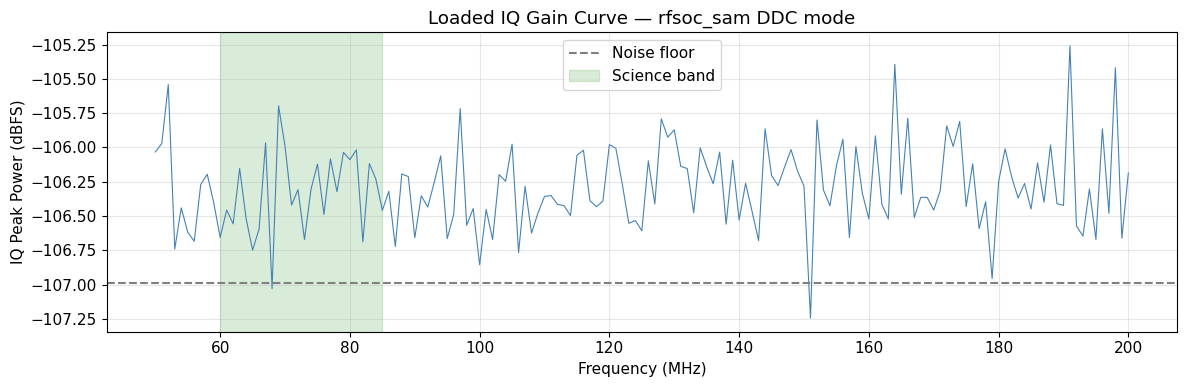

In [9]:
# Load the saved results from disk
# This cell can be run independently after the sweep has been completed

data = np.load(cal.OUTPUT_NPZ)

loaded_freqs   = data['sweep_freqs']
loaded_powers  = data['peak_powers']
loaded_noise   = float(data['noise_floor'])

print(f"Loaded {len(loaded_freqs)} frequency steps from {cal.OUTPUT_NPZ}")
print(f"Frequency range: {loaded_freqs.min():.1f}–{loaded_freqs.max():.1f} MHz")
print(f"Power range: {np.nanmin(loaded_powers):.1f} to {np.nanmax(loaded_powers):.1f} dBFS")
print(f"Noise floor: {loaded_noise:.2f} dBFS")

# Quick plot of loaded data
valid = ~np.isnan(loaded_powers)
plt.figure(figsize=(12, 4))
plt.plot(loaded_freqs[valid], loaded_powers[valid], color='steelblue', lw=0.8)
plt.axhline(loaded_noise, color='grey', linestyle='--', label='Noise floor')
plt.axvspan(60, 85, alpha=0.15, color='green', label='Science band')
plt.xlabel('Frequency (MHz)')
plt.ylabel('IQ Peak Power (dBFS)')
plt.title('Loaded IQ Gain Curve — rfsoc_sam DDC mode')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

After running all cells, you will have:

| File | Contents |
|---|---|
| `rhino_cw_results.npz` | All sweep data as numpy arrays |
| `rhino_cw_results.csv` | Same data in spreadsheet format |
| `rhino_cw_gain_curve.png` | Gain curve plot (full + science band zoom) |
| `m1_switching_speed.png` | Switching speed histogram |
| `m3_linearity.png` | Amplitude linearity plot |
| `m4_noise_floor.png` | Noise floor stability plot |